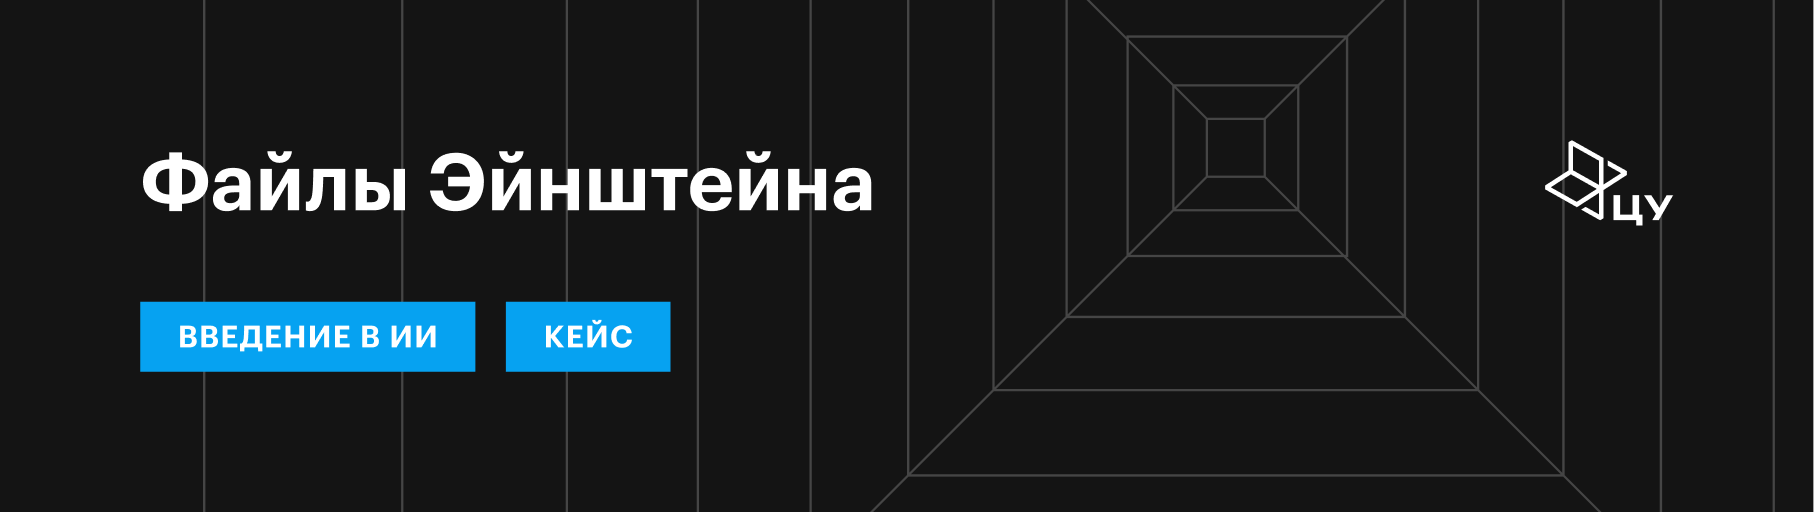

# Легенда

Ты работаешь в компании Х, которая занимается исследованием и сортировкой документов.
Недавно к тебе в руки попал ранее скрытый от глаз общественности материал *«Файлы Эйнштейна»*, содержащий тексты писем, написанных от руки великим учёным.

Один стажёр уже отсканировал файлы и начал вручную их расшифровывать. Однако старый офисный сканер оставил ошибки и артефакты на текстах, а вкупе с неразборчивым почерком Альберта Эйнштейна эта задача оказалась невыполнимой.

Поэтому твой начальник обратился к тебе с просьбой: «Сделайте так, чтобы компьютер сам всё прочитал. И чтобы потом можно было найти слово «бомба» или «антивселенная»: мало ли что там у этого Эйнштейна было на уме».

**Задача:** создать нейросетевую модель OCR (оптическое распознавание символов), которая сможет распознавать рукописный текст Эйнштейна с максимальной точностью.

# Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения.

* **Ограничение по размеру модели:** решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено.

* **Воспроизводимость:** весь код должен выполняться последовательно с первого раза. Обязательно фиксируй random_seed, а также сохраняй веса моделей и логируй эксперимент.

**Необходимые этапы решения**

1. *Обработка данных*. Внимательно изучи данные в датасете `einstein_files`. Предложи способ выделения символов из текста. Подумай, можно ли применять модель к сырым данным или нужно провести некоторые манипуляции.


2. *Выбор модели*. Напиши свою модель классификации рукописных букв английского алфавита или выбери предобученную.


3. *Решение задачи распознавания символов*. Обучение выбранной модели на датасете. Опиши, как осуществлялись подбор гиперпараметров, выбор метрики и валидация.

4. *Применение модели*. Финальный этап решения: объедини две основные составляющие в одну (выделение символов из изображения, их обработка моделью распознавания символов, составление полного текста). Результаты OCR будут проверяться по метрикам accuracy.

# Система оценивания

Решение оценивается по трём параметрам.
* **Работа с данными [4 балла].** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными. Визуализации, предобработка и очистка/обогащение датасета будут плюсом.

* **Решение задачи [4 балла].** Оценка ставится не за итоговые метрики (для простых моделей их значение может быть небольшим), а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, то это решение будет оценено в полный балл.

* **Оформление [2 балла].** Хочется, чтобы написанный код читался как хорошая книга. Для этого мы добавляем баллы за оформление, если в коде появляются визуализации, комментарии к коду и сопроводительный текст.

# Импорт библиотек

In [1]:
import os
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import gdown
import warnings

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


# Данные

Ниже написан код для скачивания датасета `einstien_files`, который содержит 46 изображений отсканированных документов с рукописным текстом на английском языке.

In [2]:
zip_path = "einstein_files.zip"

gdown.download(id="1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ")
gdown.extractall(zip_path)
os.remove(zip_path)

directory = Path('einstein_files')
images    = [cv2.imread(directory / f.name, cv2.IMREAD_GRAYSCALE) for f in directory.iterdir()]

print(f"Найдено изображений: {len(images)}")

Downloading...
From: https://drive.google.com/uc?id=1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ
To: C:\ai-intro\cases\CV case\einstein_files.zip
100%|██████████| 4.81M/4.81M [00:00<00:00, 19.1MB/s]


Найдено изображений: 46


# Визуализация
## Примеры изображений

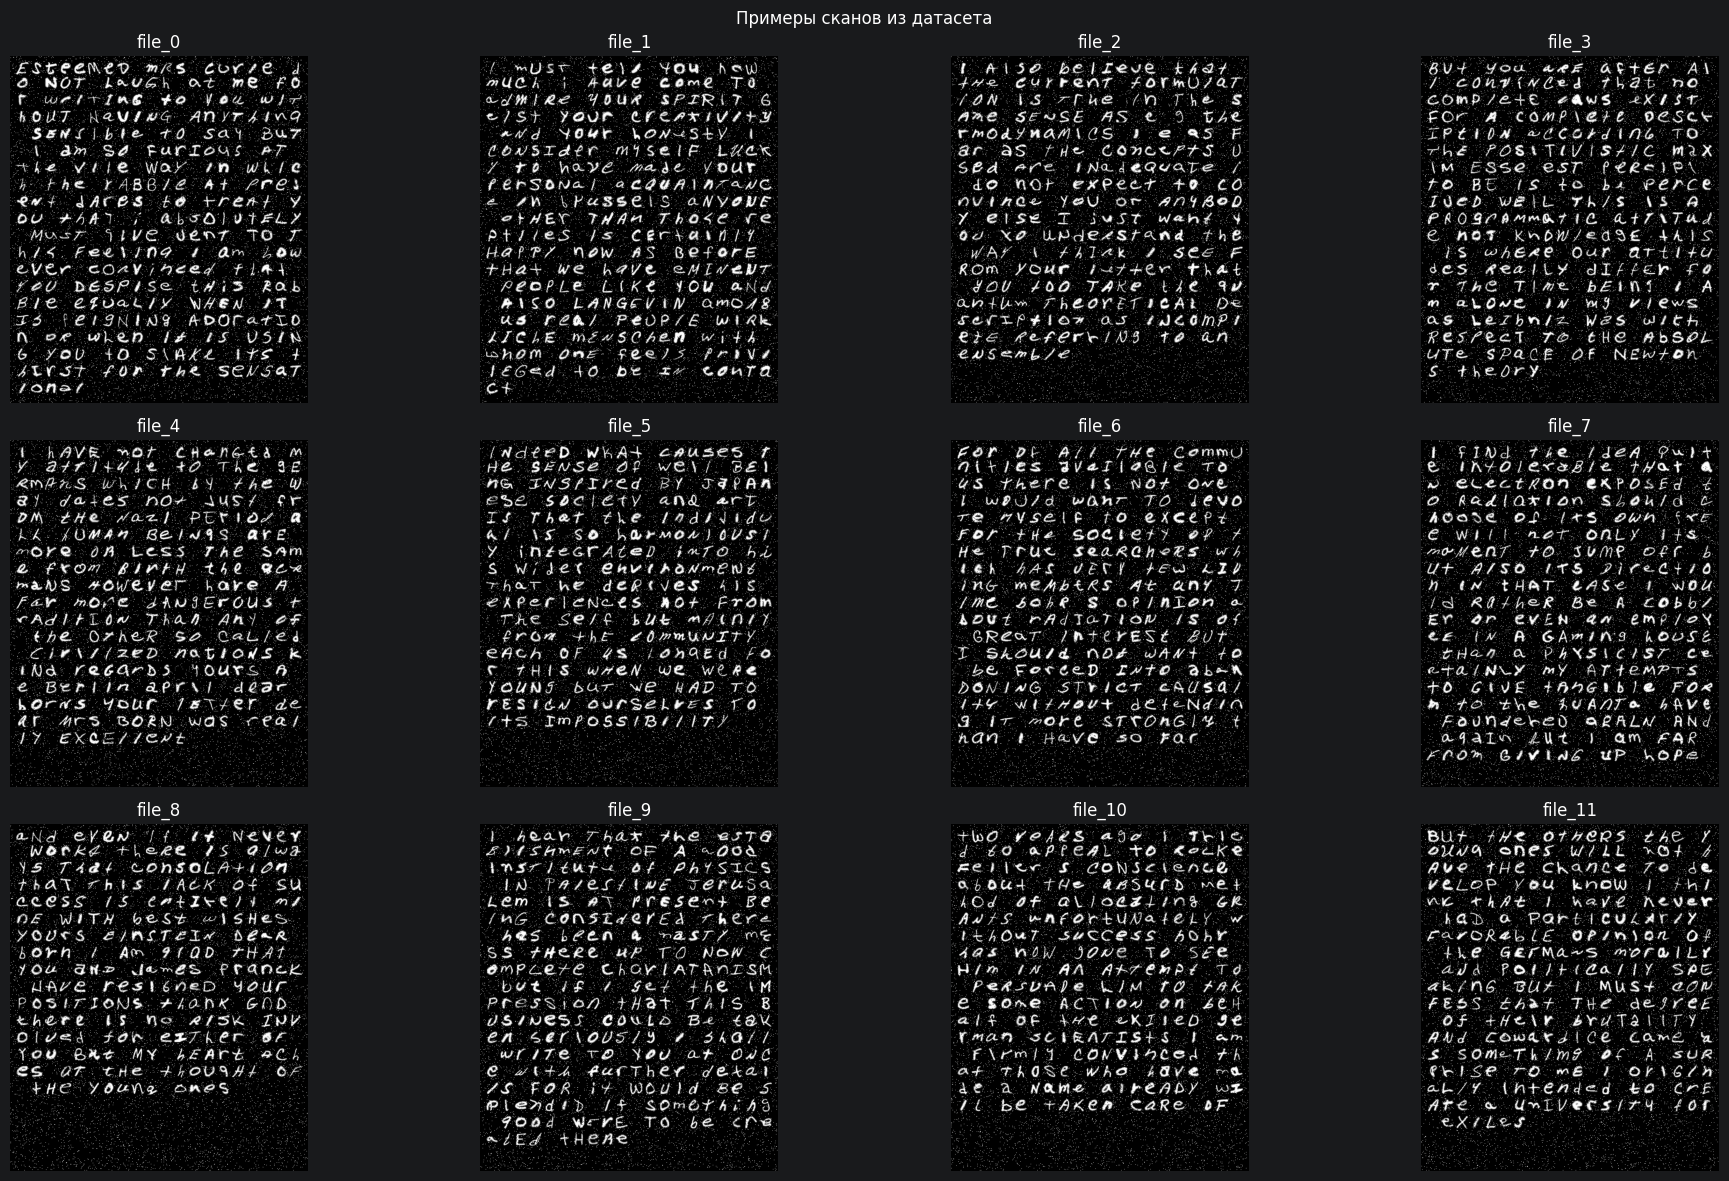

In [3]:
n_show    = min(12, len(images))
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, img in enumerate(images[:n_show]):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"file_{i}")
    axes[i].axis("off")

plt.suptitle("Примеры сканов из датасета")
plt.tight_layout()
plt.show()

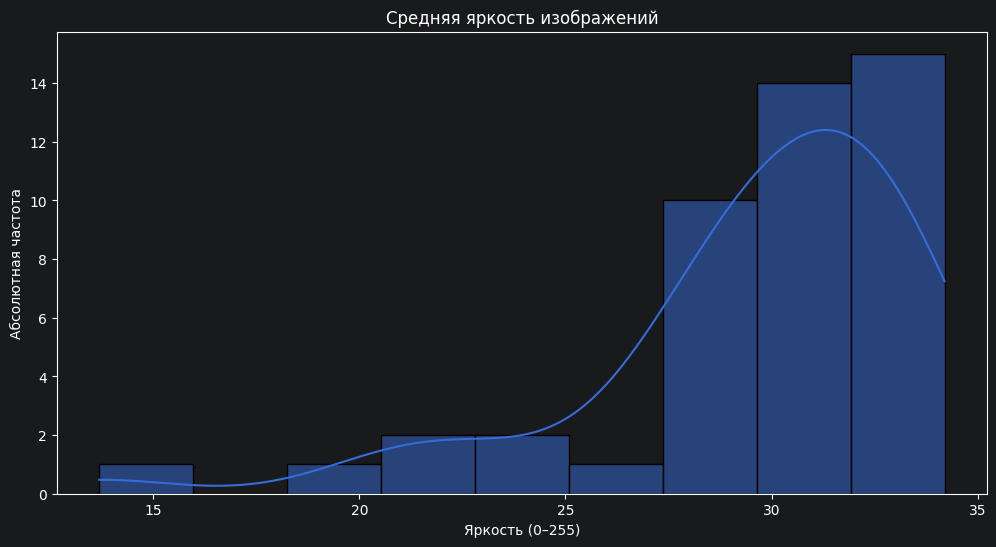

In [4]:
mean_brightness = [img.mean() for img in images]
plt.figure(figsize=(12, 6))
sns.histplot(x=mean_brightness, kde=True)
plt.title("Средняя яркость изображений")
plt.xlabel("Яркость (0–255)")
plt.ylabel("Абсолютная частота")
plt.show()

# Предобработка изображений

In [33]:
def preprocess_image(img):
    """
    Полный пайплайн предобработки:
      1. Удаление шума (bilateral filter)
      2. Морфологическая очистка
    """
    img    = cv2.medianBlur(img, ksize=3)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    img    = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=1)
    img    = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=1)

    return img

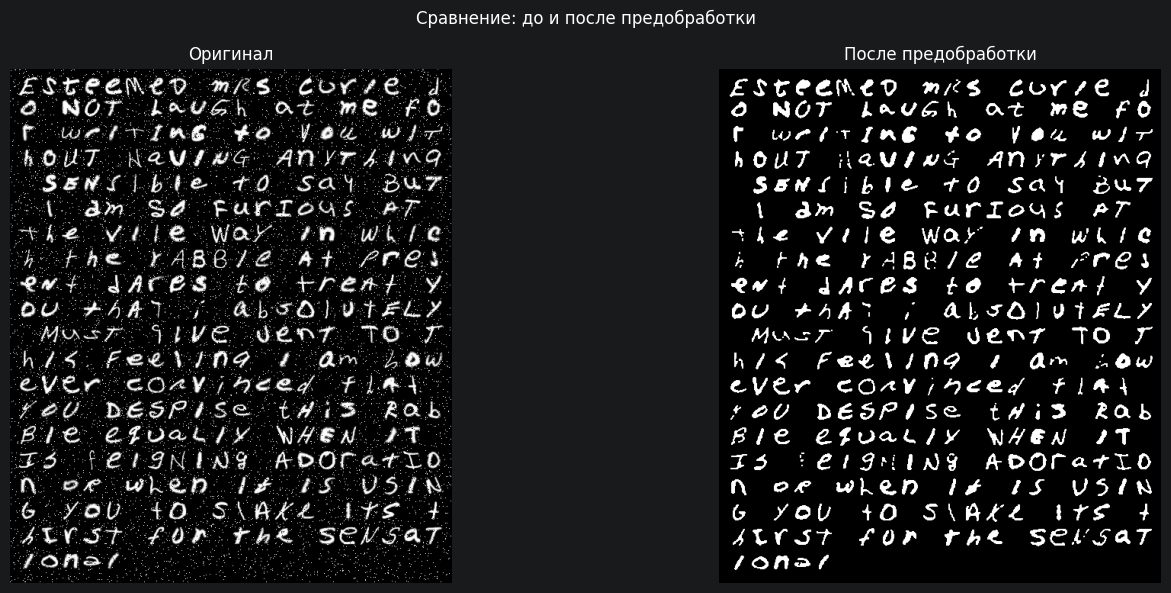

In [34]:
sample    = images[0]
processed = preprocess_image(sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (img, title) in enumerate(zip((sample, processed), ("Оригинал", "После предобработки"))):
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(title)
    axes[i].axis("off")

plt.suptitle("Сравнение: до и после предобработки")
plt.tight_layout()
plt.show()

In [35]:
preprocess_images = [preprocess_image(img) for img in tqdm(images)]

100%|██████████| 46/46 [00:00<00:00, 960.77it/s]


# Сегментация
## Сегментация строк

In [36]:
def segment_lines(
    img: np.ndarray,
    min_line_height: int = 10,
    padding: int = 5,
) -> list:
    """
    Разбиение бинарного изображения на строки текста методом горизонтальной проекции.
    Возвращает список кропов строк (bin, y_start, y_end).
    """
    h_proj = img.sum(axis=1)

    threshold = 0
    is_text = h_proj > threshold

    lines = []
    in_line = False
    start = 0
    for i, val in enumerate(is_text):
        if val and not in_line:
            start = max(i - padding, 0)
            in_line = True
        elif not val and in_line:
            end = min(i + padding, img.shape[0])
            if end - start >= min_line_height:
                line_crop = img[start:end, :]
                lines.append((line_crop, start, end))
            in_line = False
    if in_line:
        end = img.shape[0]
        if end - start >= min_line_height:
            lines.append((img[start:end, :], start, end))

    return lines

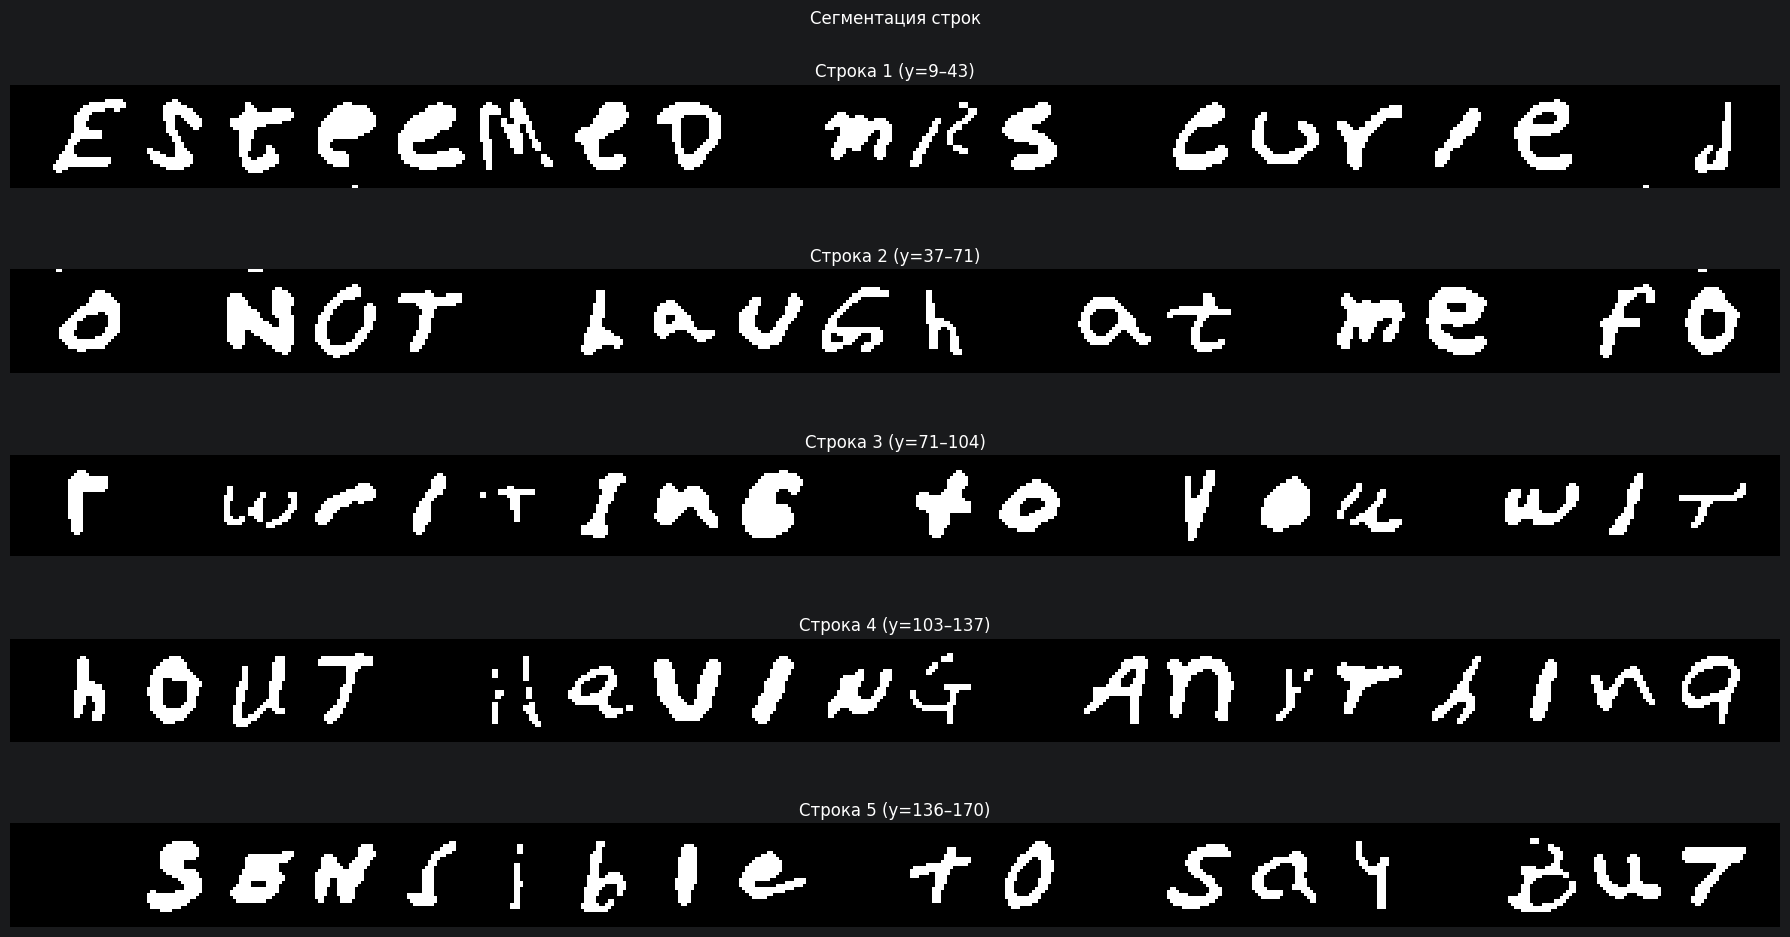

In [37]:
sample = preprocess_images[0]
lines  = segment_lines(sample)[:5]

fig, axes = plt.subplots(len(lines), 1, figsize=(18, 2 * len(lines)))
for i, (line_crop, y0, y1) in enumerate(lines):
    axes[i].imshow(line_crop, cmap="gray")
    axes[i].set_title(f"Строка {i + 1} (y={y0}–{y1})")
    axes[i].axis("off")

plt.suptitle(f"Сегментация строк", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
segmented_images = [segment_lines(img) for img in tqdm(preprocess_images)]

100%|██████████| 46/46 [00:00<00:00, 1242.20it/s]


# Fine-tune предобученной модели
## `TrOCR` (Transformer-based OCR)

TrOCR от Microsoft - модель на базе Vision Transformer + RoBERTa decoder, предобученная на IAM Handwriting и других датасетах рукописного текста. Работает на уровне строк, что упростило задачу сегментации.

In [39]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

model_name = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(model_name)
model     = VisionEncoderDecoderModel.from_pretrained(model_name).to(DEVICE)

Loading weights: 100%|██████████| 478/478 [00:00<00:00, 5311.95it/s]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
def ocr_line(line: np.ndarray, processor, model, device=DEVICE) -> str:
    """
    Распознаёт одну строку текста с помощью TrOCR.
    На вход: бинарное изображение строки (черный текст на белом фоне).
    """
    pil_img = Image.fromarray(cv2.cvtColor(255 - line, cv2.COLOR_GRAY2RGB))

    pixel_values   = processor(pil_img, return_tensors="pt").pixel_values.to(device)
    generated_ids  = model.generate(pixel_values, max_new_tokens=256)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return generated_text.strip()

In [42]:
def ocr_document(img_lines: list[np.ndarray], processor, model, device=DEVICE) -> str:
    """
    Полный пайплайн TrOCR: изображение → предобработка → строки → TrOCR → текст.
    """
    full_text_parts = []
    for line_crop, _, _ in tqdm(img_lines):
        text = ocr_line(line_crop, processor, model, device)
        full_text_parts.append(text)

    return "\n".join(full_text_parts)

In [43]:
texts = []
for scan in tqdm(segmented_images):
  texts.append(ocr_document(scan, processor, model))
text = "\n".join(texts)

100%|██████████| 20/20 [00:58<00:00,  2.94s/it]

esteemed Miss Curve )
o NOT LAUGH at me to
T WESTING to YOU WIT
HOUT HOUSING ANP.T.ING
SENSIBLE to say but
1 am 50 furious at
the V.I.I.e way in which
& The RABBLE At press
ent dares to treat y
OU THAT I absolutely
must give sent to it
hits feeling I am now
ever convinced flat .
"OU DESPISE THIS RAB
BIE EQUALITY WHEN IT
is reigring Adoratio
n or when it is us in
6 YOU to shake its t
first for the sex-sat
ional #


In [ ]:
print(text)

# Итог

В этом разделе мы подведём итоги обработки данных и обучения модели OCR. Для этого мы используем две метрики — **Character Error Rate** (CER) и **Word Error Rate** (WER).

1. CER вычисляется как расстояние Левенштейна (то есть количество замен символов, необходимое для перевода одной строки в другую) между исходным текстом и распознанным, делённое на количество символов.

2. WER вычисляется как процент совпадающих слов.

In [45]:
!pip install Levenshtein

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [rapidfuzz]
   ---------------------------------------- 2/2 [Levenshtein]



In [46]:
from Levenshtein import distance

def character_error_rate(pred_text, real_text):
    """Расстояние Левенштейна"""
    return distance(pred_text, real_text) / len(real_text)

In [47]:
def word_error_rate(pred_text, real_text):
    """Процент слов, распознанных с ошибкой"""
    pred_words = pred_text.split()
    true_words = real_text.split()

    if len(true_words) == 0:
        return 0 if len(pred_words) == 0 else 1.0

    errors = sum(1 for p, t in zip(pred_words, true_words) if p != t)
    errors += abs(len(pred_words) - len(true_words))

    return errors / len(true_words)

Напиши функцию для обработки файлов Эйнштейна. Она должна принимать на вход датасет `epstein_files` (чтение данных и их обработку ты выбираешь и реализовываешь самостоятельно) и твою модель OCR `model`. На выходе — распознанный текст.

In [ ]:
pred_text = text

Прочитай текстовый файл с реальным текстом файлов Эйнштейна и оцени качество модели с помощью метрик выше.

**ВНИМАНИЕ.** Данный файл в целях академической честности может быть прочтён и использован только в части кода снизу.

In [ ]:
gdown.download(id="1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC")

In [ ]:
with open('top_secret.txt', 'r', encoding='utf-8') as file:
    real_text = file.read().lower()

In [ ]:
wer = word_error_rate(pred_text, real_text)
cer = character_error_rate(pred_text, real_text)
print(f"WER = {wer}")
print(f"CER = {cer}")

**Выводы:** опиши, как ты пришёл(-ла) к решению, какие модели использовались, как проходил подбор гиперпараметров, как работал(а) с данными, с какими проблемами столкнулся(ась) и прочее.